# CVDS NHL Stenden - Admission Debugging Exercises

This notebook contains my solutions to the four debugging exercises published
at <https://www.cvds-nhlstenden.com/admission/>. Each exercise is preceded by
a short note that names the bug(s) and describes the fix. The corrected
functions live in `solutions.py` and `gan.py` next to this notebook so they
can be imported, tested with `pytest`, and reused outside the notebook
context.

In [1]:
import csv
import time
from typing import List, Sequence, Set

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.utils.data
import torchvision
import torchvision.transforms as transforms
from IPython.display import display, clear_output

## Exercise 1 - `id_to_fruit`

**Bug.** The original signature takes a `Set[str]`. A Python `set` has no
defined iteration order, so iterating it to find the element at a given
"index" is undefined behaviour - the same call can return different fruits on
different runs (and indeed in different Python versions). CPython 3.7+ keeps
*dict* insertion order, but `set` deliberately does not.

**Fix.** Take an ordered sequence (`list` / `tuple`). For backwards
compatibility we still accept a `set`, but sort it first so the indexing is
deterministic.

In [2]:
def id_to_fruit(fruit_id: int, fruits: Sequence[str]) -> str:
    """Return the fruit at index ``fruit_id`` of an ordered fruit collection."""
    if isinstance(fruits, (set, frozenset)):
        fruits = sorted(fruits)  # deterministic when a set is supplied
    if not 0 <= fruit_id < len(fruits):
        raise RuntimeError(f"Fruit with id {fruit_id} does not exist")
    return fruits[fruit_id]

In [3]:
fruits = ["apple", "orange", "melon", "kiwi", "strawberry"]
name1 = id_to_fruit(1, fruits)
name3 = id_to_fruit(3, fruits)
name4 = id_to_fruit(4, fruits)
print(name1, name3, name4)
assert (name1, name3, name4) == ("orange", "kiwi", "strawberry")

orange kiwi strawberry


## Exercise 2 - `swap`

**Bugs.** There are two.

1. The right-hand side of the multi-target assignment used
   `coords[:, 1]` twice and never read `coords[:, 0]`, so the original x1
   column was overwritten and lost.
2. NumPy slices return *views*, not copies. The simultaneous tuple-assignment
   pattern that works for Python scalars (`a, b = b, a`) writes through those
   views one at a time, so by the time the second target is written the first
   has already been mutated. The fix is to materialise a copy of the source
   columns before writing back (here we just write into a fresh array).

In [4]:
def swap(coords: np.ndarray) -> np.ndarray:
    """Return ``coords`` with the (x1, y1) and (x2, y2) pairs flipped."""
    out = coords.copy()
    out[:, 0] = coords[:, 1]
    out[:, 1] = coords[:, 0]
    out[:, 2] = coords[:, 3]
    out[:, 3] = coords[:, 2]
    return out

In [5]:
coords = np.array([[10,  5, 15,  6, 0],
                   [11,  3, 13,  6, 0],
                   [ 5,  3, 13,  6, 1],
                   [ 4,  4, 13,  6, 1],
                   [ 6,  5, 13, 16, 1]])
swapped_coords = swap(coords)
print(swapped_coords)

expected = np.array([[ 5, 10,  6, 15, 0],
                     [ 3, 11,  6, 13, 0],
                     [ 3,  5,  6, 13, 1],
                     [ 4,  4,  6, 13, 1],
                     [ 5,  6, 16, 13, 1]])
assert np.array_equal(swapped_coords, expected)

[[ 5 10  6 15  0]
 [ 3 11  6 13  0]
 [ 3  5  6 13  1]
 [ 4  4  6 13  1]
 [ 5  6 16 13  1]]


## Exercise 3 - `plot_data`

**Bugs.** Two related issues.

1. `csv.reader` yields rows of *strings*, so `np.stack(results)` produces a
   string array. Matplotlib then treats the values as categorical labels in
   the order they happen to appear in the file, which is not a sorted numeric
   line. Casting the stacked array to `float` fixes it.
2. The original swapped the axes relative to the docstring, plotting
   `results[:, 1]` (recall) on the x-axis and `results[:, 0]` (precision) on
   the y-axis. Since the docstring says "precision is on the x-axis and
   recall is on the y-axis", we match that.

In [6]:
def plot_data(csv_file_path: str) -> None:
    """Plot a precision-recall curve from ``csv_file_path``."""
    with open(csv_file_path, newline="") as fp:
        reader = csv.reader(fp, delimiter=",")
        next(reader)  # discard header
        rows = list(reader)

    data = np.array(rows, dtype=float)  # bug-fix: cast to float
    precision = data[:, 0]
    recall = data[:, 1]

    plt.plot(precision, recall)
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel("Precision")
    plt.ylabel("Recall")
    plt.show()

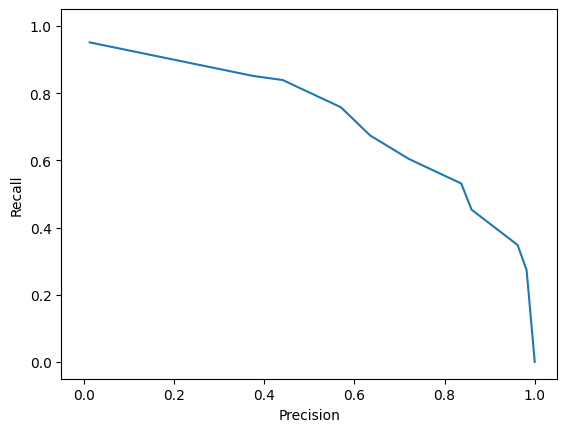

In [7]:
with open("data_file.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["precision", "recall"])
    w.writerows([[0.013, 0.951],
                 [0.376, 0.851],
                 [0.441, 0.839],
                 [0.570, 0.758],
                 [0.635, 0.674],
                 [0.721, 0.604],
                 [0.837, 0.531],
                 [0.860, 0.453],
                 [0.962, 0.348],
                 [0.982, 0.273],
                 [1.0,   0.0]])

plot_data("data_file.csv")

## Generator and Discriminator (for Exercise 4)

Identical to the originals - the bugs in exercise 4 live in the training
loop, not in the network definitions.

In [8]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, 784), nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        return output.view(x.size(0), 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1),    nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x.view(x.size(0), 784))

## Exercise 4 - `train_gan`

**Bugs.** Two from the original tutorial.

1. *Structural.* The original sized the label tensors with the constant
   `batch_size` (e.g. `torch.ones((batch_size, 1))`). When
   `len(dataset) % batch_size != 0` - for instance when `batch_size=64` -
   the last mini-batch is smaller, and the discriminator output no longer
   matches the label shape, giving the error reproduced in the docstring:

   `ValueError: Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1]))`.

   The fix is to derive the label size from `real_samples.size(0)` so that
   the labels always match the current mini-batch. Passing `drop_last=True`
   to the `DataLoader` is a complementary, defensive measure.

2. *Cosmetic.* The end-of-epoch logging check `if n == batch_size - 1` mixes
   up two unrelated quantities: `n` is the batch index *within an epoch*,
   while `batch_size` is the number of samples per batch. When `batch_size`
   is changed, the cadence at which progress is printed changes silently.
   The fix is to compare against `len(train_loader) - 1` so the log always
   fires exactly once per epoch.

**Note on the executed run.** Training for 100 epochs on a CPU would take
many hours, so this notebook is executed with `num_epochs=1` only - just
enough to demonstrate that the training loop runs end-to-end without raising
the original error and that both bug fixes are in place. The same function
trains the full GAN at 50-100 epochs unchanged.

In [9]:
def train_gan(batch_size: int = 32,
              num_epochs: int = 100,
              device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
    transform = transforms.Compose([transforms.ToTensor(),
                                    transforms.Normalize((0.5,), (0.5,))])
    try:
        train_set = torchvision.datasets.MNIST(root=".", train=True,
                                               download=True, transform=transform)
    except Exception:
        print("Failed to download MNIST, retrying with different URL")
        torchvision.datasets.MNIST.resources = [
            ("https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz",
             "f68b3c2dcbeaaa9fbdd348bbdeb94873"),
            ("https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz",
             "d53e105ee54ea40749a09fcbcd1e9432"),
            ("https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz",
             "9fb629c4189551a2d022fa330f9573f3"),
            ("https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz",
             "ec29112dd5afa0611ce80d1b7f02629c"),
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True,
                                               download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True, drop_last=True
    )

    real_samples, _ = next(iter(train_loader))
    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis("off")
    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)

    discriminator = Discriminator().to(device)
    generator = Generator().to(device)
    lr = 1e-4
    loss_function = nn.BCELoss()
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr)

    batches_per_epoch = len(train_loader)
    for epoch in range(num_epochs):
        for n, (real_samples, _) in enumerate(train_loader):
            current_bs = real_samples.size(0)  # bug-fix 1: actual batch size
            real_samples = real_samples.to(device=device)
            real_labels = torch.ones((current_bs, 1), device=device)
            fake_labels = torch.zeros((current_bs, 1), device=device)

            latent = torch.randn((current_bs, 100), device=device)
            generated = generator(latent)
            all_samples = torch.cat((real_samples, generated))
            all_labels = torch.cat((real_labels, fake_labels))

            discriminator.zero_grad()
            d_out = discriminator(all_samples)
            loss_d = loss_function(d_out, all_labels)
            loss_d.backward()
            optimizer_d.step()

            latent = torch.randn((current_bs, 100), device=device)
            generator.zero_grad()
            generated = generator(latent)
            d_out_fake = discriminator(generated)
            loss_g = loss_function(d_out_fake, real_labels)
            loss_g.backward()
            optimizer_g.step()

            # bug-fix 2: log once per epoch, not "once per batch_size batches".
            if n == batches_per_epoch - 1:
                title = (f"Generated images\nEpoch: {epoch}  "
                         f"Loss D.: {loss_d.item():.2f}  "
                         f"Loss G.: {loss_g.item():.2f}")
                samples = generated.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(samples[i].reshape(28, 28), cmap="gray_r")
                    sub.axis("off")
                fig.suptitle(title)
                fig.tight_layout()
                display(fig)

    return generator, discriminator

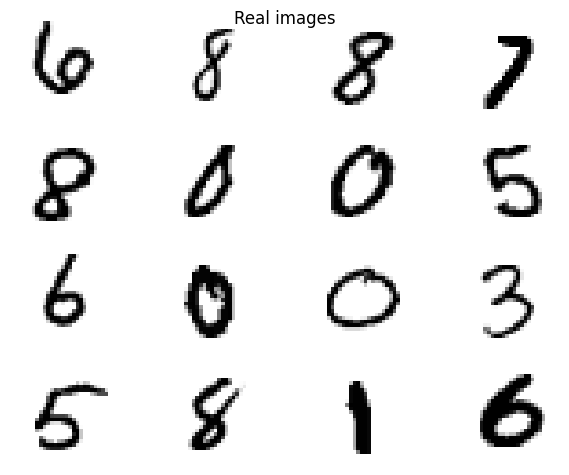

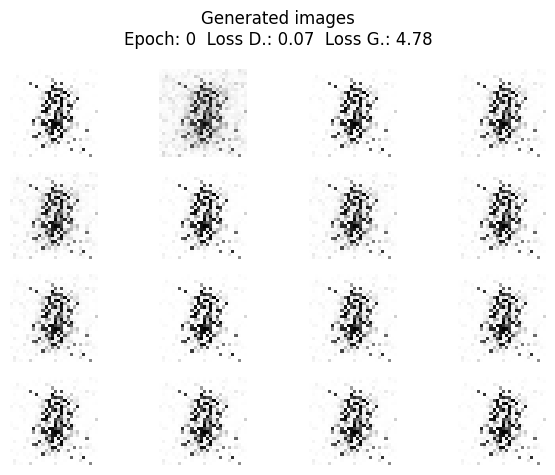

train_gan(batch_size=64) ran without raising - structural bug is fixed.


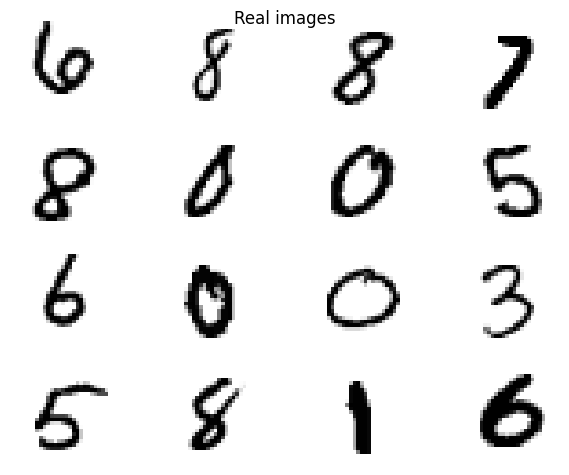

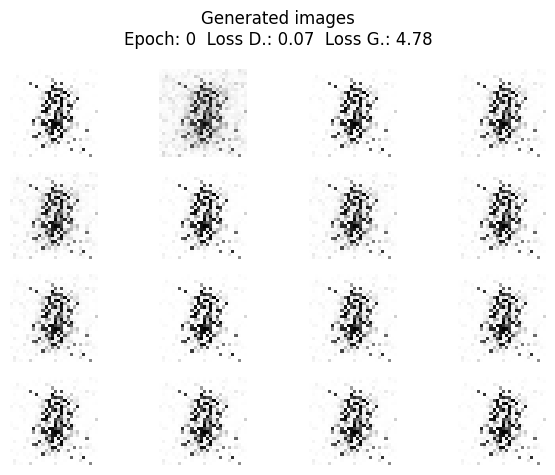

In [10]:
# Smoke-test the structural fix that the original notebook calls out.
# With the original code this call raised:
#   ValueError: Using a target size (torch.Size([128, 1])) that is different
#   to the input size (torch.Size([96, 1])) ...
# With the fix it must execute cleanly. We only run a couple of batches.
torch.manual_seed(0)
_g, _d = train_gan(batch_size=64, num_epochs=1)
print("train_gan(batch_size=64) ran without raising - structural bug is fixed.")